# Stage 0 — Per-rotor spectra & free-field propagation validation

**Goal.** Use DREGON's *constant-speed single-motor* recordings to answer three questions before we attempt any multi-rotor separation:

1. **What does a single rotor look like from each of the 8 mics?** (mean-spectrum shapes)
2. **How well does the free-field `1/r + delay` model** — the one baked into `src/models/generative/positional_harmonic_gen.py` — reproduce what the array actually measures?
3. **Where does that model break** (scattering off the airframe, near-field, spatial incoherence)?

**Why these recordings.** `DREGON_individual_motors_recordings/Motor{1..4}_{speed}.wav` spin **one** motor at a fixed speed while the full 8-mic array records. Each file is therefore a (near) single-source, 8-channel observation — exactly what you need to measure a rotor's per-mic transfer function *without* first solving separation.

**The model under test.** For a single rotor emitting `s(t)` at position $p$, the free-field prediction at mic $m$ is
$$ y_m(t) = \frac{r_\text{ref}}{r_m}\, s\!\left(t - \frac{r_m}{c}\right),\qquad r_m = \lVert p - \text{mic}_m\rVert,\ c=343\,\text{m/s}. $$
So relative to a reference mic it predicts a **frequency-independent level ratio** $r_\text{ref}/r_m$ and a **pure delay** $(r_m-r_\text{ref})/c$. Everything below tests those two claims.

> ⚠️ **Heads-up (found during this analysis):** DREGON's shipped `micPos` and `rotorsPos` are in **mismatched coordinate frames** — a ~180° rotation about *z*. Using the geometry as-is makes the propagation delays come out *anti-correlated* with reality. The notebook detects and corrects this; see the **Geometry validation** section.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# --- locate the companion module, the DREGON data, and the repo `src` ---
NB_DIR = Path.cwd()
for p in (NB_DIR, NB_DIR / "notebooks"):
    if (p / "stage0_rtf_utils.py").exists():
        sys.path.insert(0, str(p))
        break
import stage0_rtf_utils as S  # noqa: E402

DREGON = S.find_dregon_dir(NB_DIR)          # walks up; finds data/ in the main checkout
REPO = DREGON.parent.parent
sys.path.insert(0, str(REPO / "src"))
from data_processing.dregon import get_geometry  # noqa: E402

print("DREGON dir :", DREGON)
print("speeds     :", S.available_speeds(DREGON))
%matplotlib inline
plt.rcParams["figure.dpi"] = 110

DREGON dir : /home/flyingleafe/Research/PhD/projects/harmonic-noise-suppression/data/DREGON
speeds     : {1: [50, 60, 70, 80, 90], 2: [50, 60, 70, 80, 90], 3: [50, 60, 70, 80, 90], 4: [50, 60, 70, 80, 90]}


## Setup: geometry, harmonic structure, and the free-field baseline

The filename integer is the **tonal fundamental in Hz** — harmonics land at `k * speed` (verified below: `Motor1_70` peaks at 70, 140, 210, …). DREGON's rotor↔mic distances span **0.22–0.40 m**, so the free-field model predicts up to ~5 dB inter-mic level differences and ~0.5 ms (≈22 samples @ 44.1 kHz) delays — both large enough to measure.

The cell below loads all four rotors at `SPEED`, runs the **geometry frame alignment** (see the dedicated section), and builds a `GEOM` dict with both the *shipped* and *corrected* distance matrices so every later plot can switch between them.

In [ ]:
SPEED = 70          # fundamental Hz; one of 50/60/70/80/90
FMAX = 4000         # display band
SECONDS = 20        # analysis window (recordings are stationary; keeps it snappy)

# `get_geometry` now returns the 180°-z-frame-CORRECTED mic array (the fix is
# baked into `dregon._correct_mic_frame`). We recover the shipped (as-distributed,
# buggy) frame by undoing the flip so the before/after comparison below still works.
mic_pos_corr, rotor_pos = get_geometry(DREGON)
mic_pos = mic_pos_corr * np.array([-1.0, -1.0, 1.0])   # shipped frame (x, y negated back)

XS, SR = {}, None
for mid in S.MOTOR_IDS:
    x, SR = S.load_motor(DREGON, mid, SPEED, SECONDS)
    XS[mid] = x

# Motor k is assumed to correspond to rotor_pos row (k-1); the alignment sweep
# on the *shipped* frame validates the frame flip + that mapping jointly (it
# should peak near 180° with a strongly negative identity correlation).
ALIGN = S.align_mic_frame({mid - 1: XS[mid] for mid in S.MOTOR_IDS}, mic_pos, rotor_pos, SR)
GEOM = {
    "shipped":   S.distance_matrix(mic_pos, rotor_pos),       # (rotor, mic)
    "corrected": S.distance_matrix(mic_pos_corr, rotor_pos),
}
SPECS = {mid: S.mean_spectrum(XS[mid], SR) for mid in S.MOTOR_IDS}

print(f"sr = {SR} Hz")
print(f"Frame alignment: best {ALIGN.best_degrees:.1f}deg (TDOA corr {ALIGN.best_corr:.2f})  "
      f"vs identity corr {ALIGN.identity_corr:.2f}")
print("corrected rotor->mic distances (m):")
print(np.round(GEOM["corrected"], 3))

## 1 · The 8×4 mean-spectrum grid

Rows = **microphone** (0–7), columns = **rotor** (1–4). Each panel is the Welch power spectral density (dB) of one rotor as heard by one mic, at the chosen `SPEED`. Scan it to compare *shapes* across the whole array at once: the harmonic comb at `k·SPEED`, the broadband floor, and how both change from mic to mic.

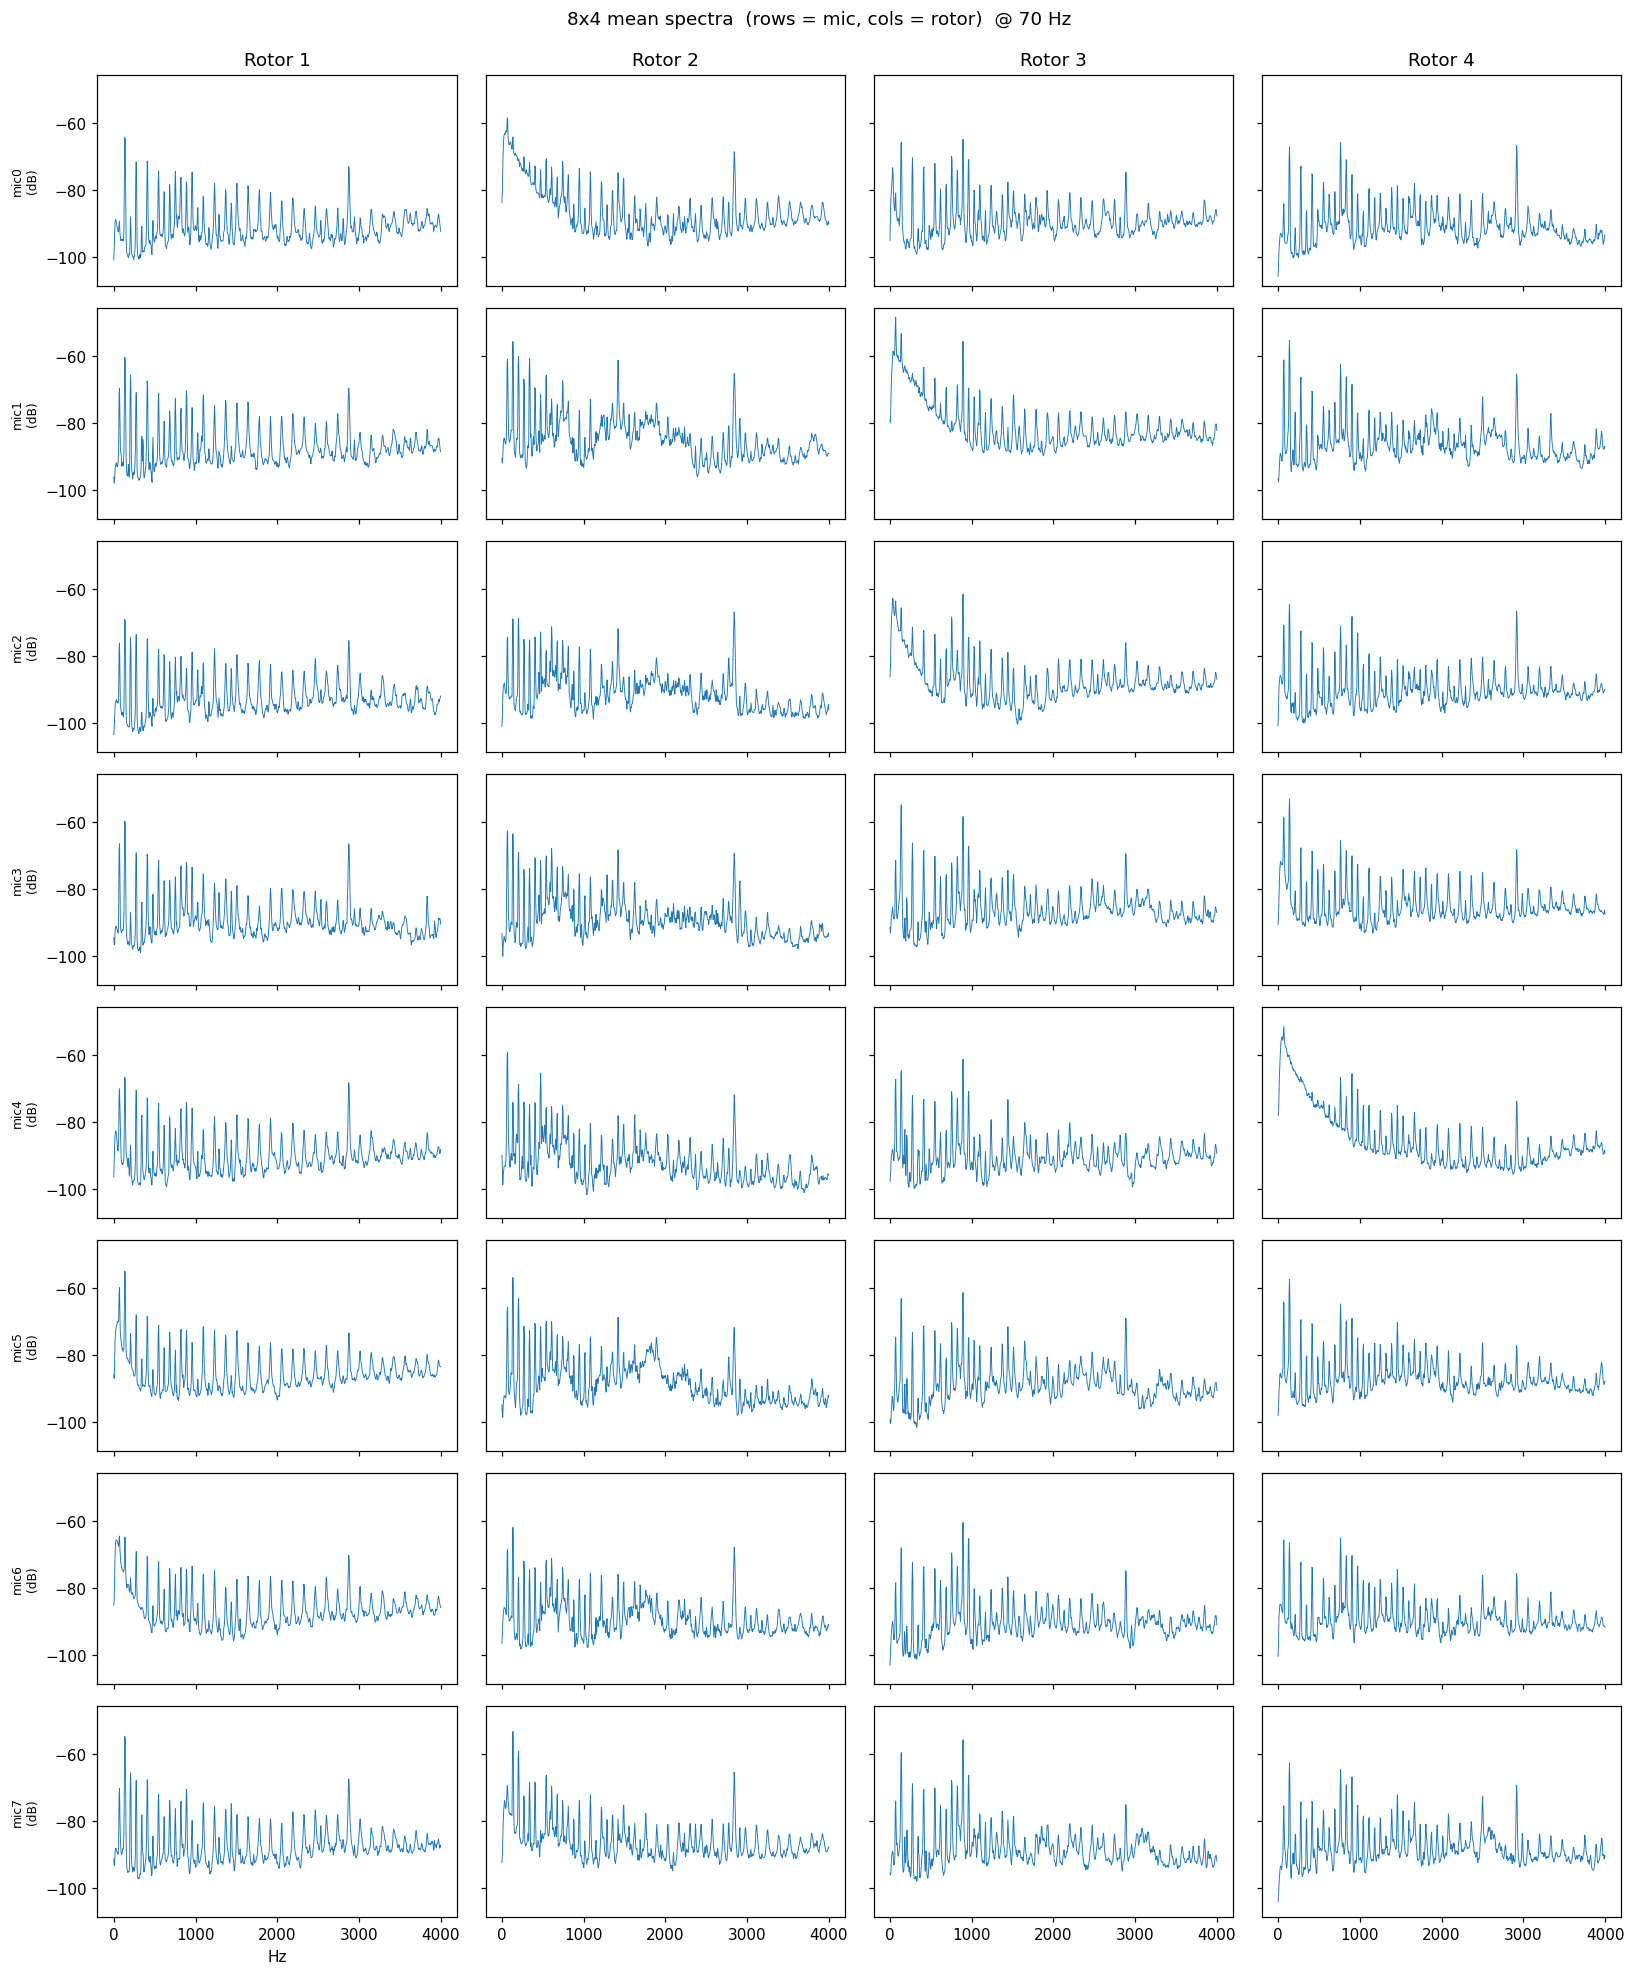

In [3]:
def plot_grid(speed=SPEED, fmax=FMAX):
    specs = {mid: S.mean_spectrum(XS[mid], SR) if speed == SPEED
             else S.mean_spectrum(S.load_motor(DREGON, mid, speed, SECONDS)[0], SR)
             for mid in S.MOTOR_IDS}
    f = specs[1][0]; band = f <= fmax
    fig, ax = plt.subplots(8, 4, figsize=(15, 18), sharex=True, sharey=True)
    for c, mid in enumerate(S.MOTOR_IDS):
        fr, P = specs[mid]
        for m in range(8):
            ax[m, c].plot(fr[band], 10 * np.log10(P[m, band] + 1e-14), lw=0.6)
            if m == 0:
                ax[m, c].set_title(f"Rotor {mid}")
            if c == 0:
                ax[m, c].set_ylabel(f"mic{m}\n(dB)", fontsize=8)
    ax[-1, 0].set_xlabel("Hz")
    fig.suptitle(f"8x4 mean spectra  (rows = mic, cols = rotor)  @ {speed} Hz", y=0.995)
    fig.tight_layout()
    plt.show()

plot_grid()

## 2 · Same rotor, different microphones (overlay)

The grid is good for scanning; to *compare mics directly* we overlay all 8 in one panel per rotor.

* **Raw** (top row): the near mic is loudest — that is the `1/r` law showing up as a level offset.
* **Distance-compensated** (bottom row): each mic PSD is multiplied by $(r_m/r_\text{min})^2$, i.e. we *undo* the free-field `1/r²` power law. **If free-field were exact, all 8 lines would collapse onto one.** Residual spread = directivity + airframe scattering + spatial incoherence — energy the single-emitter-plus-propagation model cannot explain.

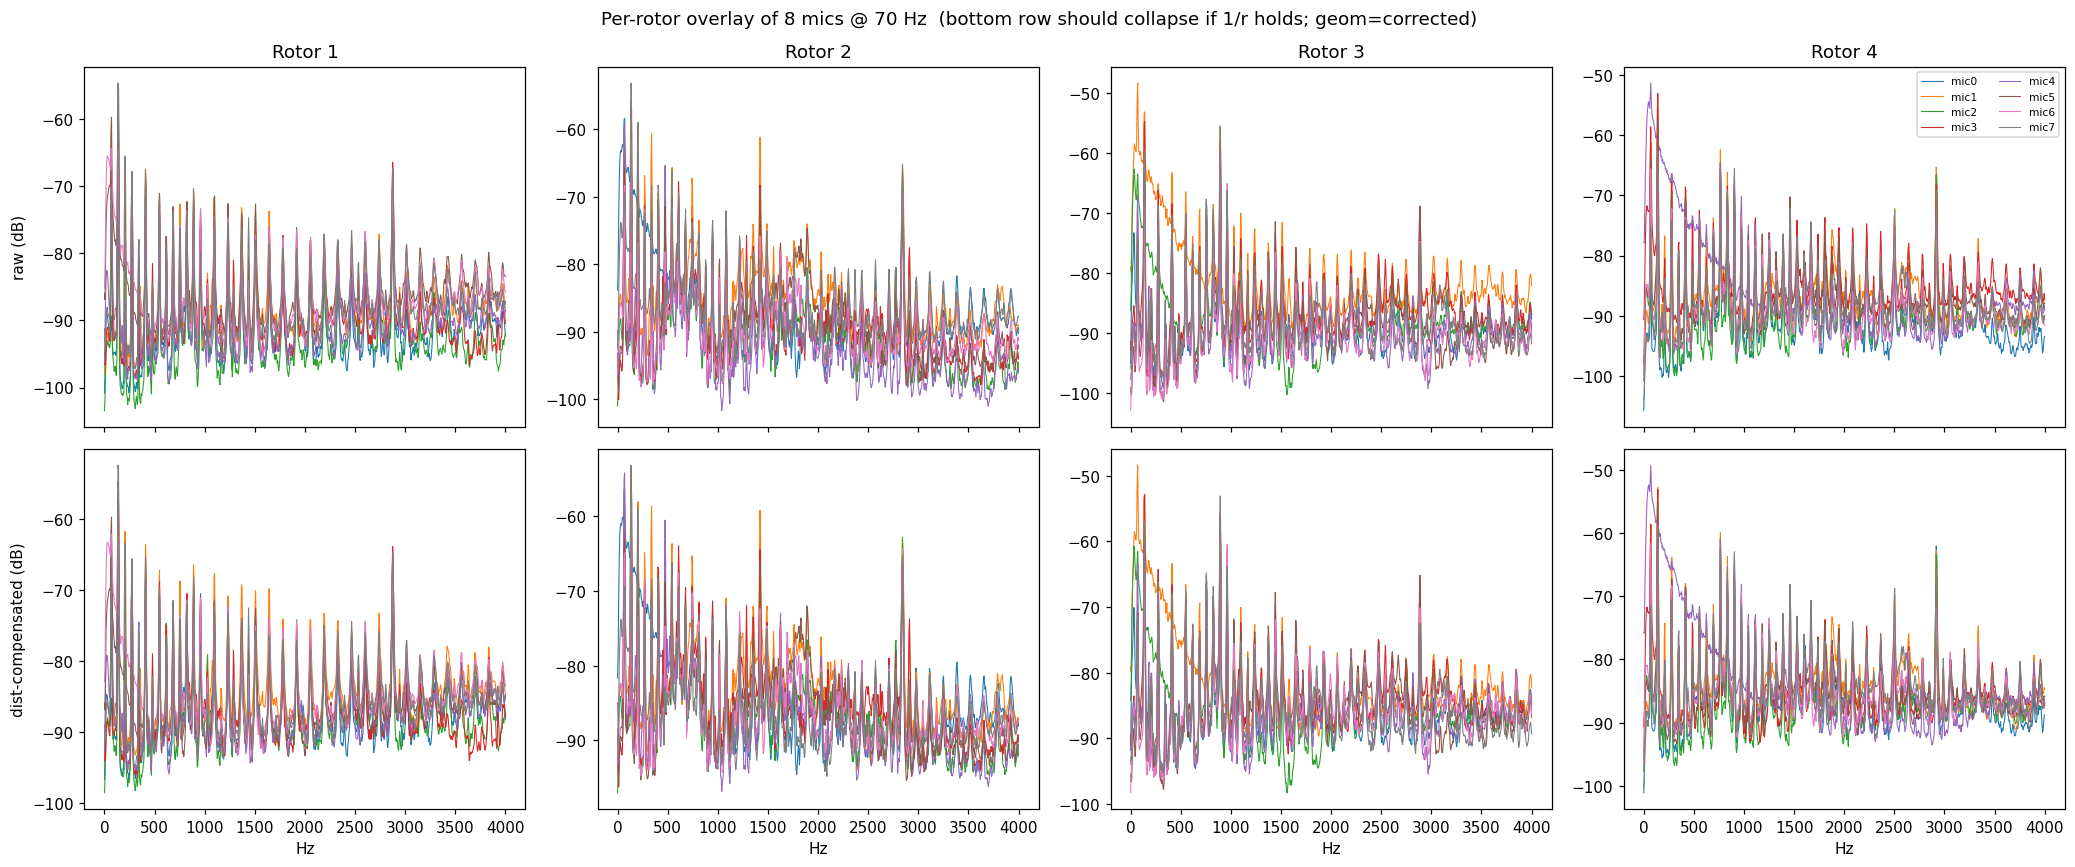

In [4]:
def plot_overlay(speed=SPEED, fmax=FMAX, geom="corrected"):
    specs = {mid: (S.mean_spectrum(XS[mid], SR) if speed == SPEED
                   else S.mean_spectrum(S.load_motor(DREGON, mid, speed, SECONDS)[0], SR))
             for mid in S.MOTOR_IDS}
    f = specs[1][0]; band = f <= fmax
    dist = GEOM[geom]
    fig, ax = plt.subplots(2, 4, figsize=(19, 8), sharex=True)
    for c, mid in enumerate(S.MOTOR_IDS):
        fr, P = specs[mid]; r = dist[mid - 1]
        for m in range(8):
            lbl = f"mic{m}" if c == 3 else None
            ax[0, c].plot(fr[band], 10 * np.log10(P[m, band] + 1e-14), lw=0.7, label=lbl)
            comp = P[m, band] * (r[m] / r.min()) ** 2
            ax[1, c].plot(fr[band], 10 * np.log10(comp + 1e-14), lw=0.7)
        ax[0, c].set_title(f"Rotor {mid}")
        ax[1, c].set_xlabel("Hz")
    ax[0, 0].set_ylabel("raw (dB)"); ax[1, 0].set_ylabel("dist-compensated (dB)")
    ax[0, 3].legend(fontsize=7, ncol=2, loc="upper right")
    fig.suptitle(f"Per-rotor overlay of 8 mics @ {speed} Hz  "
                 f"(bottom row should collapse if 1/r holds; geom={geom})")
    fig.tight_layout()
    plt.show()

plot_overlay()

## 3 · Relative Transfer Function (RTF) estimation — how it works

We never observe the rotor's emitted signal `s(t)` directly, but all 8 mics observe it *simultaneously*. That lets us estimate each mic's transfer function **relative to a reference mic**.

Model a single source: $X_m(f) = H_m(f)\,S(f) + \text{noise}_m$. The estimate of the ratio $H_m/H_\text{ref}$ that is robust to uncorrelated per-mic noise is the **cross-spectrum over the reference auto-spectrum** (a Wiener/least-squares estimator, Welch-averaged over frames to approximate the expectation):
$$ \widehat{\mathrm{RTF}}_m(f) = \frac{S_{x_m x_\text{ref}}(f)}{S_{x_\text{ref} x_\text{ref}}(f)} \;\approx\; \frac{H_m(f)}{H_\text{ref}(f)}. $$

Alongside it we compute the **magnitude-squared coherence** $\gamma^2_{m,\text{ref}}(f)$, which tells us *where the RTF is meaningful*:
* $\gamma^2 \to 1$: the two mics see the **same coherent source** at that frequency → RTF trustworthy.
* $\gamma^2$ low: energy at mic $m$ is **uncorrelated** with the reference (broadband turbulence, scattered/reverberant paths) → **no** linear single-source model (free-field *or* measured) can reproduce it.

The **free-field RTF** to compare against is simply
$$ \mathrm{RTF}^{\text{ff}}_m(f) = \underbrace{\frac{r_\text{ref}}{r_m}}_{\text{flat magnitude}}\; \underbrace{e^{-j 2\pi f (r_m - r_\text{ref})/c}}_{\text{pure delay}}. $$

Below: measured $|\mathrm{RTF}|$ (blue) vs free-field (orange, flat) per mic, with coherence (green, right axis). Deviation of blue from orange = **directivity / scattering**; where green is low, *both* are unreliable. The reference-mic panel is trivial ($\equiv 1$) and is annotated as such.

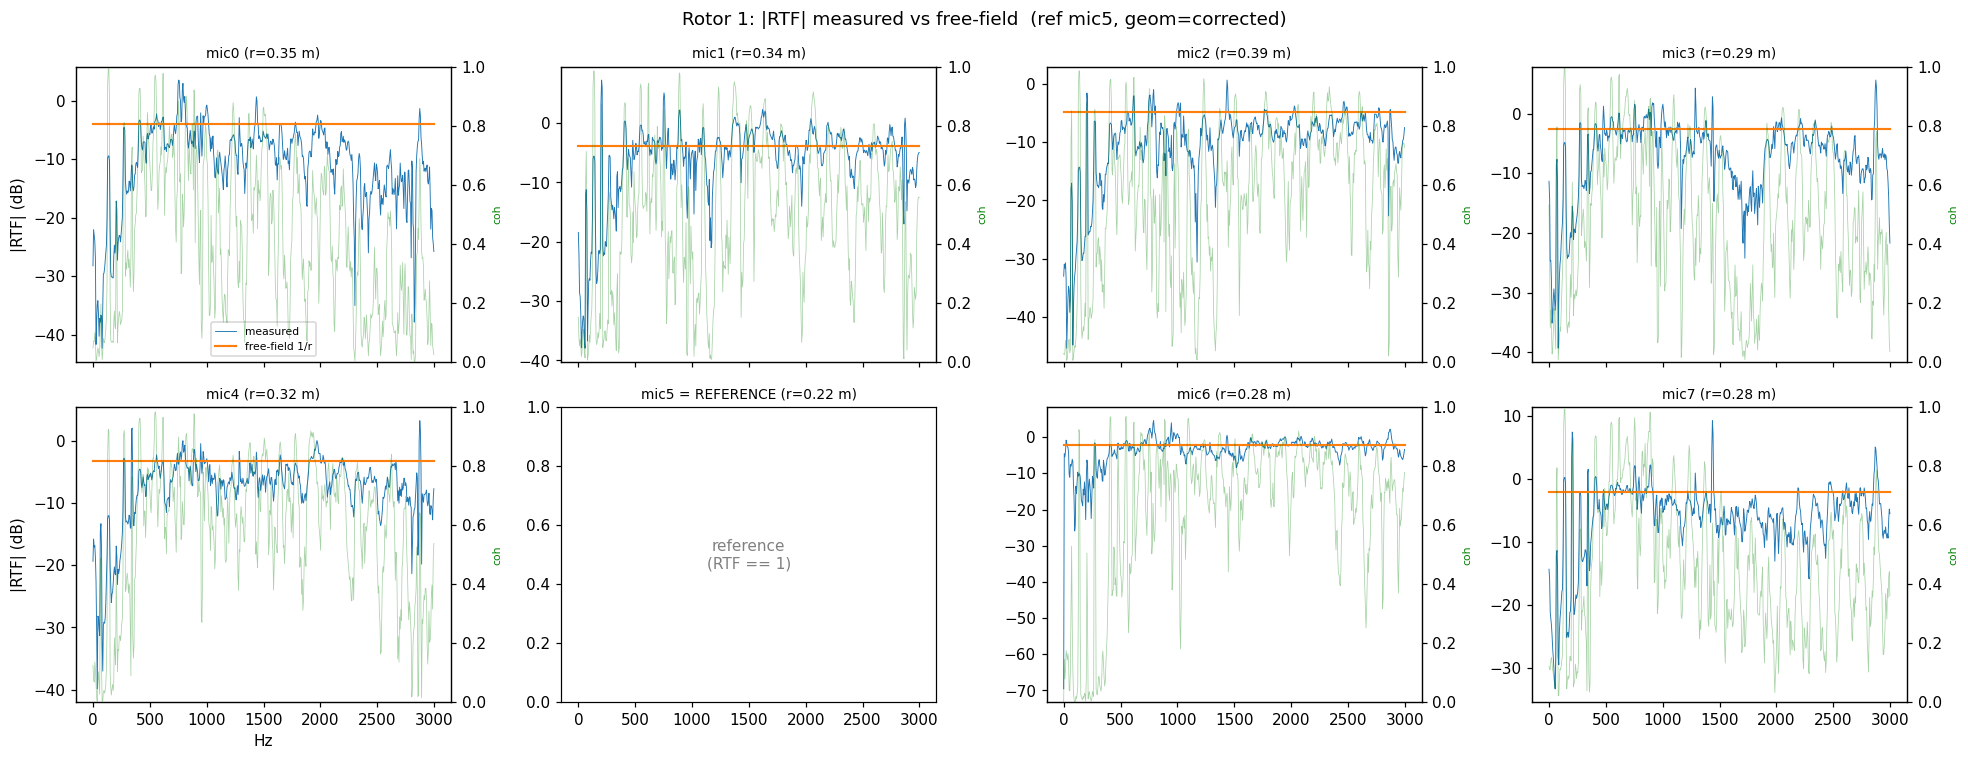

In [5]:
def plot_rtf(rotor=1, geom="corrected", fmax=3000, ref=None):
    dist = GEOM[geom][rotor - 1]
    if ref is None:
        ref = int(np.argmin(dist))            # nearest mic = highest-SNR reference
    fr, H, CO = S.estimate_rtf(XS[rotor], SR, ref)
    Hff = S.freefield_rtf(fr, dist, ref)
    sb = fr <= fmax
    fig, ax = plt.subplots(2, 4, figsize=(18, 7), sharex=True)
    for m in range(8):
        a = ax[m // 4, m % 4]
        if m == ref:
            a.set_title(f"mic{m} = REFERENCE (r={dist[m]:.2f} m)", fontsize=9)
            a.text(0.5, 0.5, "reference\n(RTF == 1)", ha="center", va="center",
                   transform=a.transAxes, color="gray")
            continue
        a.plot(fr[sb], 20 * np.log10(np.abs(H[m, sb]) + 1e-9), lw=0.6, label="measured")
        a.plot(fr[sb], 20 * np.log10(np.abs(Hff[m, sb]) + 1e-9), lw=1.4, label="free-field 1/r")
        a2 = a.twinx(); a2.plot(fr[sb], CO[m, sb], color="green", lw=0.5, alpha=0.35)
        a2.set_ylim(0, 1); a2.set_ylabel("coh", color="green", fontsize=7)
        a.set_title(f"mic{m} (r={dist[m]:.2f} m)", fontsize=9)
        if m == 0 or (ref == 0 and m == 1):
            a.legend(fontsize=7, loc="lower center")
    ax[1, 0].set_xlabel("Hz"); ax[0, 0].set_ylabel("|RTF| (dB)"); ax[1, 0].set_ylabel("|RTF| (dB)")
    fig.suptitle(f"Rotor {rotor}: |RTF| measured vs free-field  (ref mic{ref}, geom={geom})")
    fig.tight_layout()
    plt.show()

plot_rtf(rotor=1)

### Coherence-weighted magnitude error

One number per mic: the coherence-weighted mean $|\,|\mathrm{RTF}|_\text{meas} - |\mathrm{RTF}|_\text{ff}\,|$ over 80–2500 Hz (dB). This is how far the **level** part of the free-field model is off, focused on frequencies where the RTF is well-defined. We show *shipped* vs *corrected* geometry; the corrected frame should reduce the spread.

mean |error|  shipped = 1.56 dB   corrected = 2.54 dB


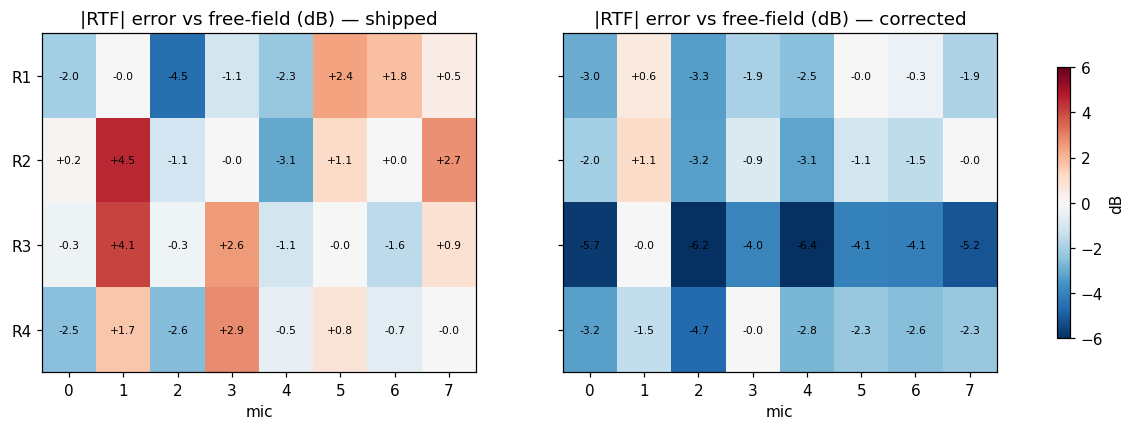

In [6]:
def mag_error_table(geom="corrected", band=(80.0, 2500.0)):
    rows = []
    for mid in S.MOTOR_IDS:
        dist = GEOM[geom][mid - 1]; ref = int(np.argmin(dist))
        fr, H, CO = S.estimate_rtf(XS[mid], SR, ref)
        Hff = S.freefield_rtf(fr, dist, ref)
        rows.append(S.coherence_weighted_mag_error(H, Hff, CO, fr, band))
    return np.array(rows)  # (rotor, mic)

err_ship = mag_error_table("shipped")
err_corr = mag_error_table("corrected")
fig, ax = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for a, err, tag in ((ax[0], err_ship, "shipped"), (ax[1], err_corr, "corrected")):
    im = a.imshow(err, aspect="auto", cmap="RdBu_r", vmin=-6, vmax=6)
    a.set_xticks(range(8)); a.set_yticks(range(4)); a.set_yticklabels([f"R{m}" for m in S.MOTOR_IDS])
    a.set_xlabel("mic"); a.set_title(f"|RTF| error vs free-field (dB) — {tag}")
    for i in range(4):
        for j in range(8):
            a.text(j, i, f"{err[i, j]:+.1f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8, label="dB")
print(f"mean |error|  shipped = {np.abs(err_ship).mean():.2f} dB   "
      f"corrected = {np.abs(err_corr).mean():.2f} dB")
plt.show()

## 4 · Geometry validation (the 180° frame mismatch)

**Delay is the sharp test of geometry.** We measure the true rotor→mic delays with **GCC-PHAT** (a whitened cross-correlation TDOA estimator, robust for broadband content) and compare against the free-field prediction $(r_m-r_\text{ref})/c$, sweeping a rotation of the mic frame about *z*.

* **Left:** correlation between measured and predicted TDOAs vs mic-frame z-rotation. The shipped frame (0°) sits at a strongly *negative* correlation; the peak is near **180°**.
* **Right:** measured vs predicted TDOA scatter. **Shipped** (gray) scatters off the diagonal (even anti-diagonal); **corrected** (orange) hugs $y=x$.

**Takeaway:** the delay physics of the free-field model is actually *good* — once the frame mismatch is fixed. Any downstream use of this geometry (the generator's `propagate`, beamforming, informed separation) should apply the same ~180° correction. This should be reconciled against DREGON's own axis conventions before being treated as a hard bug.

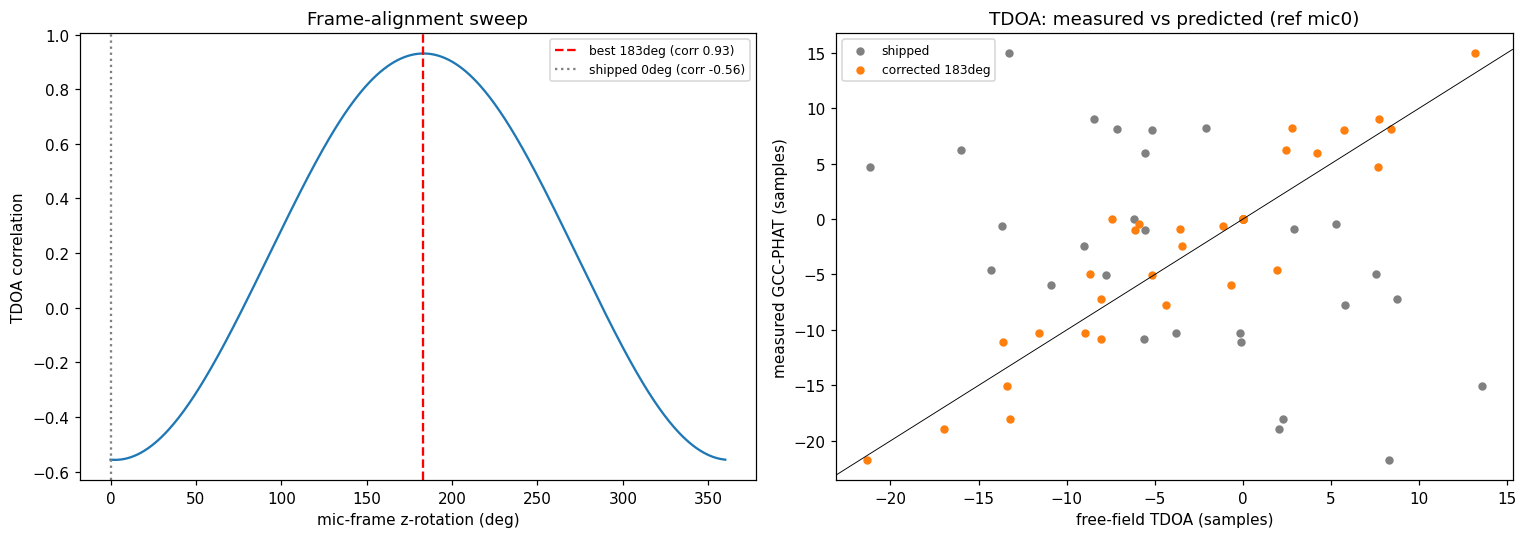

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(ALIGN.angles, ALIGN.corr_curve)
ax[0].axvline(ALIGN.best_degrees, color="r", ls="--",
              label=f"best {ALIGN.best_degrees:.0f}deg (corr {ALIGN.best_corr:.2f})")
ax[0].axvline(0, color="gray", ls=":", label=f"shipped 0deg (corr {ALIGN.identity_corr:.2f})")
ax[0].set_xlabel("mic-frame z-rotation (deg)"); ax[0].set_ylabel("TDOA correlation")
ax[0].set_title("Frame-alignment sweep"); ax[0].legend(fontsize=8)

meas = np.vstack([S.measured_tdoa_row(XS[mid], 0) for mid in S.MOTOR_IDS]).ravel()
for tag, mp, col in (("shipped", mic_pos, "gray"),
                     (f"corrected {ALIGN.best_degrees:.0f}deg", mic_pos_corr, "C1")):
    d = S.distance_matrix(mp, rotor_pos)
    pred = np.vstack([S.freefield_tdoa_row(d[mid - 1], 0, SR) for mid in S.MOTOR_IDS]).ravel()
    ax[1].scatter(pred, meas, s=20, color=col, label=tag)
ax[1].axline((0, 0), slope=1, color="k", lw=0.6)
ax[1].set_xlabel("free-field TDOA (samples)"); ax[1].set_ylabel("measured GCC-PHAT (samples)")
ax[1].set_title("TDOA: measured vs predicted (ref mic0)"); ax[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

## 5 · Interactive: real spectrum vs `1/r + delay` propagation, per mic

Pick a **rotor**, **speed**, **reference mic**, and **geometry**. For each of the 8 mics the plot overlays:

* **Real** (solid): the measured mic-$m$ magnitude spectrum.
* **Free-field predicted** (dashed): the reference-mic spectrum propagated to mic $m$ by the pure `1/r` law, i.e. shifted by $20\log_{10}(r_\text{ref}/r_m)$ dB. *(Delay does not affect magnitude — it is reported as a number instead.)*
* **Coherence** (faint, right axis): where it is low, the real spectrum is intrinsically un-predictable from any single reference.

Each subplot title reports the **free-field vs measured delay** (samples) — the delay half of the model. Where solid≈dashed *and* the two delays agree *and* coherence is high, the free-field model holds; departures localise exactly where (and in which frequency band) it fails.

In [8]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as W
from IPython.display import display

_LOAD, _RTF = {}, {}

def _specs(mid, spd):
    if (mid, spd) not in _LOAD:
        x, sr = S.load_motor(DREGON, mid, spd, SECONDS)
        _LOAD[(mid, spd)] = (x, sr, *S.mean_spectrum(x, sr))
    return _LOAD[(mid, spd)]

def _coh_delay(mid, spd, ref):
    if (mid, spd, ref) not in _RTF:
        x, sr, _, _ = _specs(mid, spd)
        fr, _, CO = S.estimate_rtf(x, sr, ref)
        _RTF[(mid, spd, ref)] = (CO, S.measured_tdoa_row(x, ref))
    return _RTF[(mid, spd, ref)]

_speeds = sorted(set.intersection(*[set(v) for v in S.available_speeds(DREGON).values()]))
w_rotor = W.Dropdown(options=list(S.MOTOR_IDS), value=1, description="Rotor")
w_speed = W.Dropdown(options=_speeds, value=70 if 70 in _speeds else _speeds[0], description="Speed Hz")
w_ref = W.Dropdown(options=list(range(8)), value=5, description="Ref mic")
w_geom = W.Dropdown(options=["corrected", "shipped"], value="corrected", description="Geometry")
_out = W.Output()

def _build():
    mid, spd, ref, geom = w_rotor.value, w_speed.value, w_ref.value, w_geom.value
    x, sr, f, P = _specs(mid, spd)
    r = GEOM[geom][mid - 1]
    CO, dmeas = _coh_delay(mid, spd, ref)
    dff = S.freefield_tdoa_row(r, ref, sr)
    band = f <= FMAX
    titles = [f"mic{m}  dff={dff[m]:+.1f} dmeas={dmeas[m]:+.1f} samp" for m in range(8)]
    fig = make_subplots(rows=2, cols=4, shared_xaxes=True,
                        specs=[[{"secondary_y": True}] * 4] * 2, subplot_titles=titles)
    for m in range(8):
        rr, cc = m // 4 + 1, m % 4 + 1
        real_db = 10 * np.log10(P[m, band] + 1e-14)
        pred_db = 10 * np.log10(P[ref, band] + 1e-14) + 20 * np.log10(r[ref] / r[m])
        fig.add_scatter(x=f[band], y=real_db, name="real", legendgroup="real",
                        line=dict(color="royalblue", width=1), showlegend=(m == 0), row=rr, col=cc)
        fig.add_scatter(x=f[band], y=pred_db, name="free-field 1/r", legendgroup="ff",
                        line=dict(color="orange", width=1.6, dash="dash"), showlegend=(m == 0), row=rr, col=cc)
        fig.add_scatter(x=f[band], y=CO[m, band], name="coherence", legendgroup="coh",
                        line=dict(color="green", width=0.8), opacity=0.4, showlegend=(m == 0),
                        row=rr, col=cc, secondary_y=True)
        fig.update_yaxes(range=[0, 1], showgrid=False, secondary_y=True, row=rr, col=cc)
    fig.update_annotations(font_size=11)
    fig.update_layout(height=640, width=1150, margin=dict(t=80),
                      title=f"Rotor {mid} @ {spd} Hz - real vs free-field(1/r) from ref mic{ref} [{geom}]")
    return fig

def _update(*_):
    with _out:
        _out.clear_output(wait=True)
        _build().show()

for w in (w_rotor, w_speed, w_ref, w_geom):
    w.observe(_update, names="value")
display(W.HBox([w_rotor, w_speed, w_ref, w_geom]), _out)
_update()

Output()

## Stage-0 findings

1. **Geometry bug surfaced.** Shipped `micPos`/`rotorsPos` frames disagree by ~180° about *z* (identity TDOA correlation ≈ −0.55 → +0.93 after correction). Fix before any geometry-dependent step; reconcile with DREGON's documented axes.
2. **Delay half of free-field: good** once the frame is corrected — measured TDOAs track $(r_m-r_\text{ref})/c$ closely.
3. **Level half: roughly right, few-dB wrong.** `1/r` explains the gross inter-mic level ordering, but directivity/scattering leave a few-dB, frequency-dependent residual (see the coherence-weighted error map and the non-flat measured `|RTF|`).
4. **Spatial coherence ceiling.** A single rotor is only *partially* coherent across the array (γ² ≈ 0.5–0.7 at far mics, even at harmonic peaks). A substantial fraction of the energy — broadband/turbulent and scattered — is **not** reproducible by *any* single-emitter + linear-propagation model, free-field or measured-RTF. This bounds how faithfully the single-rotor generator can ever match a real multi-mic mixture.

**Implications for the plan.** Feed the *corrected* geometry (and, optionally, the measured RTFs) into the generator's `propagate` stage and into any informed separation. Treat the tonal comb as the well-modelled part and the incoherent broadband floor as a residual the propagation model is not expected to capture.